# Capítulo 3 — Termodinâmica da Atmosfera: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | parcela adiabática como EDO; conservação de $\theta$ | `scipy.solve_ivp` |
| 2 | ciclo diurno da superfície: balanço de energia com Bowen | `scipy.solve_ivp` |
| 3 | **advecção 1D como EDP** — nossa primeira previsão | NumPy (upwind) |
| 4 | $\theta$ e $\theta_v$ da sondagem real; camada de mistura | `MetPy` |

Exercícios numéricos N1–N4 no fim; soluções em `cap03_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

# constantes do Cap. 3 (Stull)
Cp, Cv = 1004.0, 717.0    # J kg-1 K-1
Rd, g  = 287.0, 9.8
Lv     = 2.5e6            # J/kg
Gamma_d = g/Cp            # K/m
print(f'Γd = g/Cp = {Gamma_d*1e3:.2f} K/km')

Γd = g/Cp = 9.76 K/km


## Caso 1 — A parcela adiabática e o rótulo conservado

Subida adiabática: $dT/dz = -g/c_p$. A cada altura, calculamos a pressão (hipsométrica do Cap. 1) e a temperatura potencial **exata**
$$\theta = T\left(\frac{P_0}{P}\right)^{R_d/c_p}.$$
Se a física está certa, $\theta$ não pode variar nem um milikelvin.

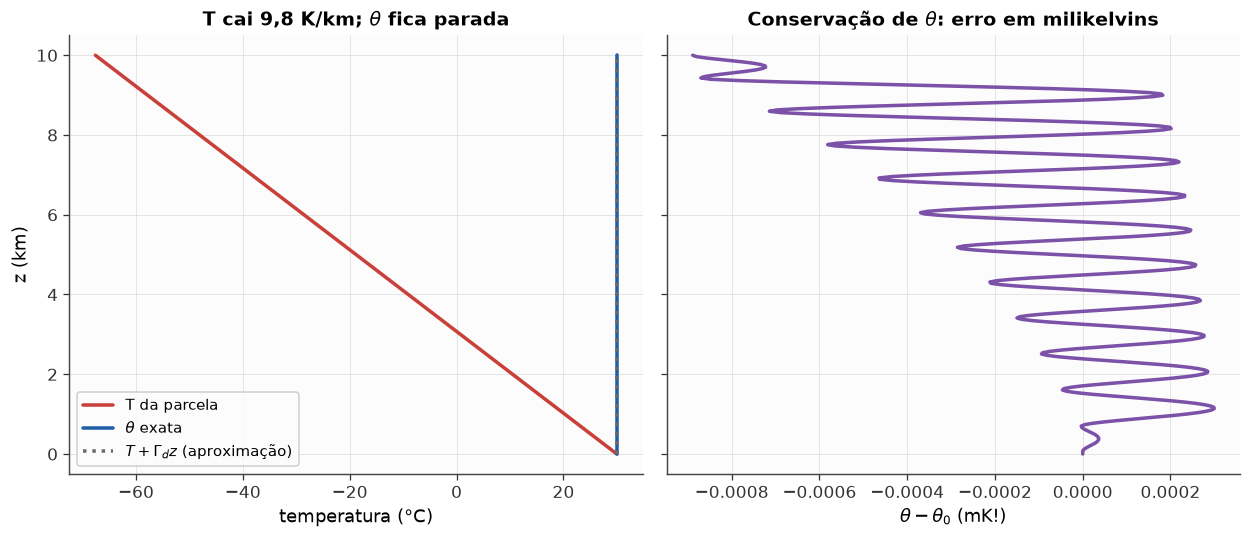

variação total de θ em 10 km de subida: 0.00 mK  (conservada ✓)
erro da aproximação T+Γd·z a 10 km: 0.0 K


In [2]:
T0, P0 = 303.15, 100.0    # parcela de 30 °C partindo de 100 kPa

def parcela(z, y):
    T, P = y
    rho = P*1e3/(Rd*T)
    return [-g/Cp, -rho*g/1e3]      # dT/dz, dP/dz (kPa/m)

z = np.linspace(0, 10e3, 300)
sol = solve_ivp(parcela, [0, 10e3], [T0, P0], t_eval=z, rtol=1e-10)
T_p, P_p = sol.y
theta_exata = T_p*(P0/P_p)**(Rd/Cp)
theta_aprox = T_p + Gamma_d*z

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
ax1.plot(T_p - 273.15, z/1e3, color=CORES['vermelho'], label='T da parcela')
ax1.plot(theta_exata - 273.15, z/1e3, color=CORES['azul'], label='$\\theta$ exata')
ax1.plot(theta_aprox - 273.15, z/1e3, ':', color=CORES['cinza'],
         label='$T + \\Gamma_d z$ (aproximação)')
ax1.set(xlabel='temperatura (°C)', ylabel='z (km)',
        title='T cai 9,8 K/km; $\\theta$ fica parada')
ax1.legend()

ax2.plot((theta_exata - theta_exata[0])*1e3, z/1e3, color=CORES['roxo'])
ax2.set(xlabel='$\\theta - \\theta_0$ (mK!)',
        title='Conservação de $\\theta$: erro em milikelvins')
fig.tight_layout(); plt.show()
print(f'variação total de θ em 10 km de subida: '
      f'{abs(theta_exata[-1]-theta_exata[0])*1e3:.2f} mK  (conservada ✓)')
print(f'erro da aproximação T+Γd·z a 10 km: '
      f'{abs(theta_aprox[-1]-theta_exata[-1]):.1f} K')

## Caso 2 — O ciclo diurno: deserto, floresta e oceano

Modelo de "laje" para a temperatura da superfície $T_s$:
$$C\frac{dT_s}{dt} = (1-A)\,S(t) \;-\; \varepsilon\sigma\bigl(T_s^4 - T_{céu}^4\bigr) \;-\; \underbrace{h\,(T_s - T_{ar})}_{F_H}\;-\;\underbrace{F_H/\beta^{-1}}_{F_E = F_H/\beta}$$

A mesma radiação, três destinos: deserto ($\beta=5$, laje leve), floresta ($\beta=0{,}2$), oceano ($\beta=0{,}1$, laje enorme).

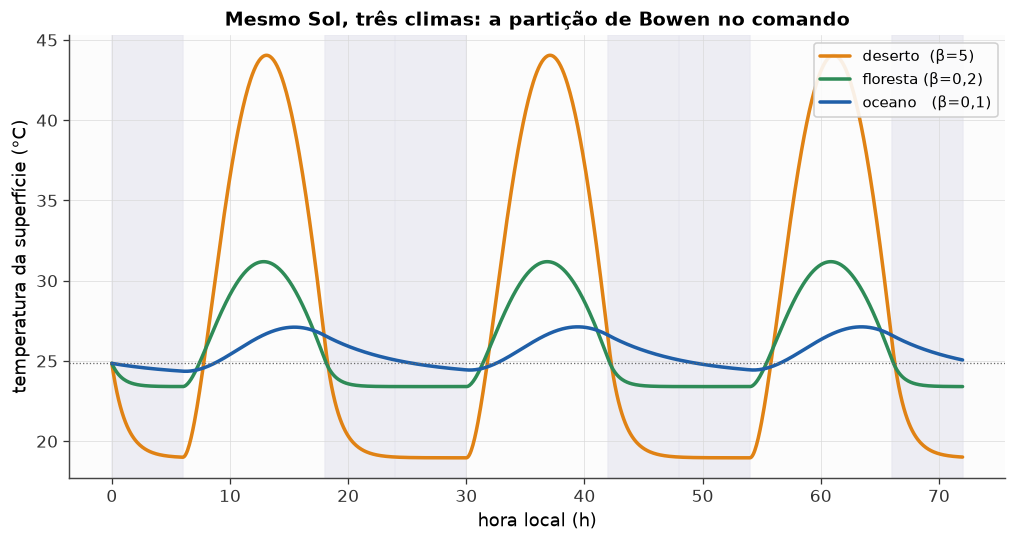

In [3]:
sigma_SB, eps = 5.67e-8, 0.95
T_ar, T_ceu = 298.0, 270.0
h_turb = 15.0                       # W m-2 K-1
S_max = 900.0                       # W m-2 ao meio-dia

def S_solar(t_h):
    return np.maximum(0.0, S_max*np.sin(np.pi*((t_h % 24) - 6)/12))

def balanço(t_h, Ts, C, A, beta):
    FH = h_turb*(Ts[0] - T_ar)
    FE = FH/beta if beta > 0 else 0.0
    dTs = ((1-A)*S_solar(t_h) - eps*sigma_SB*(Ts[0]**4 - T_ceu**4)
           - FH - FE) / C * 3600     # por hora
    return [dTs]

t = np.linspace(0, 72, 1000)        # 3 dias
superficies = [
    ('deserto  (β=5)',   1.0e5, 0.30, 5.0, CORES['laranja']),
    ('floresta (β=0,2)', 3.0e5, 0.15, 0.2, CORES['verde']),
    ('oceano   (β=0,1)', 4.0e6, 0.06, 0.1, CORES['azul']),
]

fig, ax = plt.subplots(figsize=(10.5, 5))
for dia in range(3):                 # sombrear as noites
    ax.axvspan(dia*24, dia*24 + 6, color='#e8e8f0', alpha=0.7, zorder=0)
    ax.axvspan(dia*24 + 18, (dia+1)*24, color='#e8e8f0', alpha=0.7, zorder=0)
for nome, C, A, beta, cor in superficies:
    sol = solve_ivp(balanço, [0, 72], [T_ar], args=(C, A, beta),
                    t_eval=t, max_step=0.1)
    ax.plot(t, sol.y[0] - 273.15, color=cor, label=nome)
ax.axhline(T_ar - 273.15, color=CORES['cinza'], lw=0.8, ls=':')
ax.set(xlabel='hora local (h)', ylabel='temperatura da superfície (°C)',
       title='Mesmo Sol, três climas: a partição de Bowen no comando')
ax.legend(loc='upper right')
plt.show()

**Discussão.** O deserto dispara a mais de 40 °C de tarde e despenca à noite (laje leve + nada para evaporar); a floresta modera gastando energia em evaporação; o oceano mal se move (capacidade térmica gigante). Amplitude e defasagem do máximo são o exercício N2.

## Caso 3 — Advecção 1D: a primeira previsão do curso

$$\frac{\partial T}{\partial t} = -U\,\frac{\partial T}{\partial x}$$

Uma frente fria (degrau suave de 10 K) sendo carregada por um vento de 10 m/s. Esquema *upwind*: $T_i^{n+1} = T_i^n - \frac{U\Delta t}{\Delta x}(T_i^n - T_{i-1}^n)$. A solução exata é a forma inicial deslocada de $U t$ (exercício T4) — vamos ver o quanto o esquema a borra.

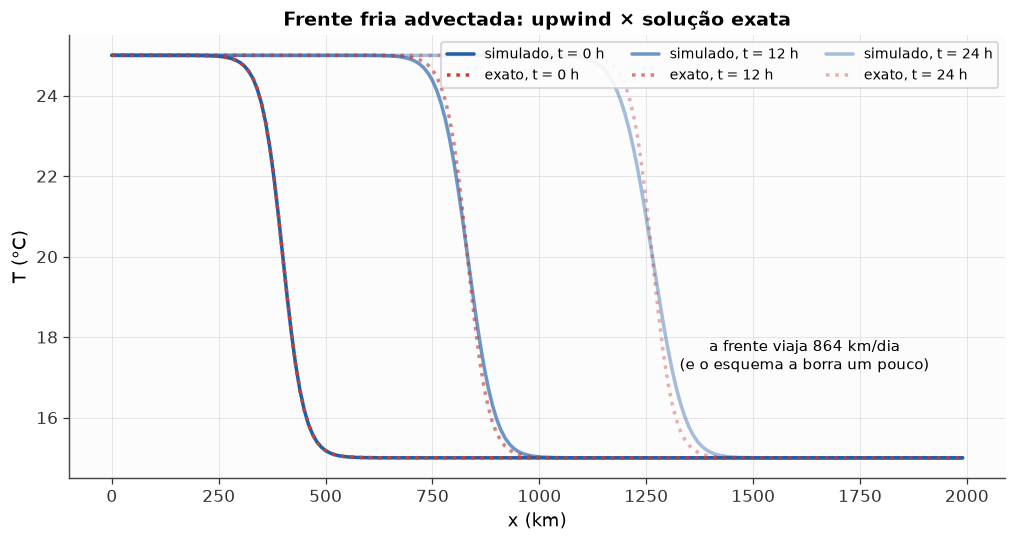

deslocamento em 24 h: U·t = 864 km ✓


In [4]:
L, U = 2000e3, 10.0                  # domínio 2000 km, vento 10 m/s
dx = 10e3                            # resolução 10 km
x = np.arange(0, L, dx)
dt = 0.8*dx/U                        # número de Courant 0,8

def frente(x, centro):
    return 25.0 - 5.0*(1 + np.tanh((x - centro)/50e3))   # 25 °C → 15 °C

T = frente(x, 400e3)
T_hist, t_hist = [T.copy()], [0.0]
t_fim = 24*3600
t_sim = 0.0
while t_sim < t_fim:
    T[1:] = T[1:] - U*dt/dx*(T[1:] - T[:-1])   # upwind (U>0)
    t_sim += dt
    if any(abs(t_sim - alvo) < dt/2 for alvo in [12*3600, 24*3600]):
        T_hist.append(T.copy()); t_hist.append(t_sim)

fig, ax = plt.subplots(figsize=(10.5, 5))
tons = [1.0, 0.65, 0.4]
for (Th, th, tom) in zip(T_hist, t_hist, tons):
    ax.plot(x/1e3, Th, color=CORES['azul'], alpha=tom,
            label=f'simulado, t = {th/3600:.0f} h')
    ax.plot(x/1e3, frente(x, 400e3 + U*th), ls=':', color=CORES['vermelho'],
            alpha=tom, label=f'exato, t = {th/3600:.0f} h')
ax.annotate('a frente viaja 864 km/dia\n(e o esquema a borra um pouco)',
            xy=(1620, 17.2), fontsize=9.5, ha='center')
ax.set(xlabel='x (km)', ylabel='T (°C)',
       title='Frente fria advectada: upwind × solução exata')
ax.legend(fontsize=8.5, ncols=3, loc='upper right')
plt.show()
print(f'deslocamento em 24 h: U·t = {U*86400/1e3:.0f} km ✓')

**Discussão.** O esquema acerta a *posição* da frente (advecção correta) mas suaviza o degrau — **difusão numérica**, o preço do upwind. Modelos operacionais usam esquemas de alta ordem para pagar menos esse preço (Cap. 20). Quantificação no exercício N3.

## Caso 4 — $\theta$ na sondagem real: achando a camada de mistura

Na vertical, $\theta$ separa os regimes: $\theta$ constante = camada bem misturada (convecção); $\theta$ crescendo = estratificação estável. Voltamos à sondagem tropical do Cap. 1, agora com os óculos do Cap. 3.

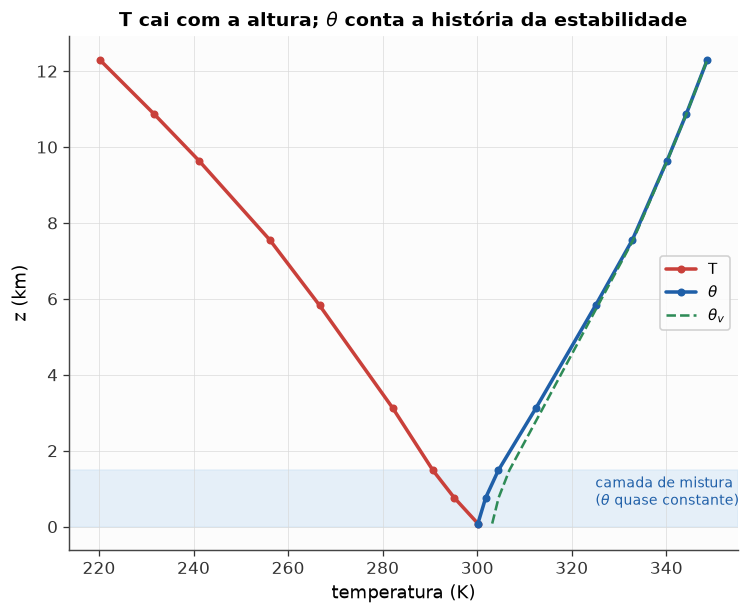

gradiente de θ por camada (K/km) — positivo = estável:
   0.08– 0.76 km:  +2.4
   0.76– 1.48 km:  +3.7
   1.48– 3.12 km:  +4.9
   3.12– 5.83 km:  +4.7
   5.83– 7.55 km:  +4.5
   7.55– 9.64 km:  +3.5
   9.64–10.87 km:  +3.3
  10.87–12.30 km:  +3.1


In [5]:
from metpy.units import units
import metpy.calc as mpcalc

P_s  = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200]) * units.hPa
z_s  = np.array([80, 760, 1480, 3120, 5830, 7550, 9640, 10870, 12300]) * units.m
T_s  = np.array([27.0, 22.0, 17.5, 9.0, -6.5, -17.0, -32.0, -41.5, -53.0]) * units.degC
Td_s = np.array([22.0, 19.0, 15.0, 5.0, -14.0, -28.0, -45.0, -55.0, -68.0]) * units.degC

theta   = mpcalc.potential_temperature(P_s, T_s).to('K')
r_s     = mpcalc.mixing_ratio_from_relative_humidity(
             P_s, T_s, mpcalc.relative_humidity_from_dewpoint(T_s, Td_s))
theta_v = mpcalc.virtual_potential_temperature(P_s, T_s, r_s).to('K')

fig, ax = plt.subplots(figsize=(7.5, 5.8))
ax.plot(T_s.to('K'), z_s.to('km'), color=CORES['vermelho'], marker='o',
        ms=4, label='T')
ax.plot(theta, z_s.to('km'), color=CORES['azul'], marker='o', ms=4,
        label='$\\theta$')
ax.plot(theta_v, z_s.to('km'), color=CORES['verde'], ls='--', lw=1.6,
        label='$\\theta_v$')
ax.axhspan(0, 1.5, color='#cfe3f5', alpha=0.5)
ax.text(325, 0.55, 'camada de mistura\n($\\theta$ quase constante)',
        fontsize=9, color=CORES['azul'])
ax.set(xlabel='temperatura (K)', ylabel='z (km)',
       title='T cai com a altura; $\\theta$ conta a história da estabilidade')
ax.legend()
plt.show()

print('gradiente de θ por camada (K/km) — positivo = estável:')
dtheta_dz = np.diff(theta.magnitude)/np.diff(z_s.magnitude)*1e3
for i, gz in enumerate(dtheta_dz):
    print(f'  {z_s[i].magnitude/1e3:5.2f}–{z_s[i+1].magnitude/1e3:5.2f} km: '
          f'{gz:+5.1f}')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap03_solucoes.ipynb`**.

**N1** — Integre a subida adiabática (Caso 1) e verifique a conservação de $\theta$; compare a fórmula exata com $\theta \approx T + \Gamma_d z$ e trace o erro da aproximação até 10 km.

**N2** — No modelo do Caso 2, compare uma superfície "continental" ($C = 10^5$ J m⁻² K⁻¹) com uma "oceânica" ($C = 4\times10^6$): amplitude do ciclo diurno e hora do máximo de $T_s$.

**N3** — Repita o Caso 3 com $\Delta x = 5, 10, 20, 40$ km (mesmo Courant) e meça a largura da frente após 24 h (distância entre os pontos de 24 °C e 16 °C). Trace largura × resolução.

**N4** — Calcule $\theta_v$ da sondagem e estime o topo da camada de mistura como o nível em que $\theta_v$ excede o valor de superfície em mais de 0,5 K.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*